# ชุดข้อมูลที่ถูกตัดออก: ตรวจซ้ำด้วยข้อมูลจริงว่าใช้กับ swarm learning ได้ไหม

ก่อนหน้านี้ตัดห้าชุดนี้ออกจากการคัดเลือกโดยอาศัยเอกสารและเปเปอร์เป็นหลัก โน้ตบุ๊กนี้เอาข้อมูลจริงมาวัดว่า
**เหตุผลที่ตัดออกถูกไหม** และ **มีเงื่อนไขไหนที่ยังใช้ได้**

| ชุดข้อมูล | ไฟล์ที่ใช้วัด | ที่มา | เปเปอร์ |
|---|---|---|---|
| CIC-IDS2017 | 2 มิเรอร์: ฉบับต้นฉบับ 79 คอลัมน์ · ฉบับที่แก้ป้ายแล้ว 89 คอลัมน์ (มี IP) | [UNB](https://www.unb.ca/cic/datasets/ids-2017.html) · HF: [c01dsnap](https://huggingface.co/datasets/c01dsnap/CIC-IDS2017), [bvk](https://huggingface.co/datasets/bvk/CICIDS-2017) | Sharafaldin et al., ICISSP 2018 · การแก้ป้าย: Engelen et al., *Troubleshooting an Intrusion Detection Dataset: the CICIDS2017 Case Study*, 2021 |
| CICIoT2023 | มิเรอร์ย่อ 1.34 ล้านแถว (parquet) | [UNB](https://www.unb.ca/cic/datasets/iotdataset-2023.html) · HF: [lacg030175/CIC-IoT-2023-raw](https://huggingface.co/datasets/lacg030175/CIC-IoT-2023-raw) | Neto et al., *CICIoT2023*, Sensors 2023 |
| TON_IoT | telemetry ของ IoT 7 ประเภท · ระบบปฏิบัติการ 5 ไฟล์ · network 1 ไฟล์ | [UNSW](https://research.unsw.edu.au/projects/toniot-datasets) · HF: [IoT](https://huggingface.co/datasets/SilverDragon9/UNSW_TON-IoT_Train_Test_IoT_Datasets), [OS](https://huggingface.co/datasets/SilverDragon9/UNSW_TON-IoT_Train_Test_OS_Datasets), [network](https://huggingface.co/datasets/codymlewis/TON_IoT_network) | Moustafa, *Network TON_IoT datasets*, Sustainable Cities and Society 2021 |
| Edge-IIoTset | `ML-EdgeIIoT-dataset.csv` (157,800 แถว) | [Kaggle](https://www.kaggle.com/datasets/mohamedamineferrag/edgeiiotset-cyber-security-dataset-of-iot-iiot) · HF: [Sunayanajagadesh/ML_EdgeIIoT_dataset](https://huggingface.co/datasets/Sunayanajagadesh/ML_EdgeIIoT_dataset) | Ferrag et al., *Edge-IIoTset*, IEEE Access 2022 |
| TII-SSRC-23 | **ไม่ได้โหลด** (Kaggle ต้องล็อกอิน) ประเมินจากเอกสารอย่างเดียว | [Kaggle](https://www.kaggle.com/datasets/daniaherzalla/tii-ssrc-23) · [arXiv 2310.10661](https://arxiv.org/abs/2310.10661) | Herzalla et al., IEEE Access 2023 |

การเทียบวิธีแบ่ง client ที่งานวิจัยอื่นใช้ อ้างจาก
[Dataset-centric evaluation of federated intrusion detection models in IoT networks](https://www.nature.com/articles/s41598-025-32567-w) (Scientific Reports)

## ข้อควรระวังเรื่องที่มาของข้อมูล

- **ลิงก์ดาวน์โหลดทางการของ UNB (CIC-IDS2017, CICIoT2023) ตอนนี้ redirect ไปหน้าเว็บ ไม่ส่งไฟล์แล้ว** จึงต้องใช้มิเรอร์บน HuggingFace ซึ่งเป็นสำเนาของบุคคลที่สาม
  ไม่ใช่ไฟล์ต้นฉบับ อาจถูกตัดหรือแปลงมาแล้ว ตัวเลขทุกตัวในโน้ตบุ๊กนี้จึงหมายถึง "ไฟล์ที่มิเรอร์ให้มา"
- **ระหว่างโหลดเจอไฟล์เสียเงียบๆ สองครั้ง**: ไฟล์ว่าง 0 ไบต์ (`Train_Test_Windows_7.csv`) และไฟล์ที่โหลดไม่ครบ
  (`Thursday-WorkingHours-Afternoon-Infilteration`: 66.1 MB จาก 83.1 MB) ซึ่งทำให้เกือบสรุปผิดว่า "มิเรอร์ขาดข้อมูล 55,740 แถว"
  ตรวจแก้แล้วโดยเทียบขนาดทุกไฟล์กับที่ HF ระบุ (36 ไฟล์ ตรงทั้งหมด) แล้วนับแถวใหม่ได้ 2,830,743 แถวเต็ม

## เกณฑ์ตัดสินว่าใช้กับ swarm learning ได้ไหม

swarm learning ต้องมีหลายหน่วยงานที่ต่างเก็บข้อมูลของตัวเอง และช่วยกันเทรนโมเดลโดยไม่ส่งข้อมูลดิบให้กัน
ชุดข้อมูลที่เหมาะจึงต้องมีคุณสมบัติหกข้อนี้ (ใช้ชื่อ S1–S6 ตลอดทั้งไฟล์)

| ข้อ | คำถาม | ทำไมสำคัญ |
|---|---|---|
| **S1** | ในข้อมูลมีคอลัมน์ที่บอกว่าแถวไหนเป็นของหน่วยงานไหน (อุปกรณ์ / เครื่อง / ที่ตั้ง) ไหม | ถ้าไม่มี ก็ต้องแบ่งเอง ซึ่งเทียบข้ามงานวิจัยไม่ได้ |
| **S2** | แต่ละหน่วยงานมีทั้งข้อมูลปกติและข้อมูลโจมตีไหม | หน่วยงานที่มีคลาสเดียวเทรนหรือทดสอบเองไม่ได้ |
| **S3** | ฟีเจอร์เหมือนกันทุกหน่วยงานไหม | ถ้าไม่เหมือน โมเดลตัวเดียวใช้ร่วมกันไม่ได้ |
| **S4** | โมเดลที่เรียนจากหน่วยงานอื่นใช้กับหน่วยงานที่ไม่เคยเห็นได้ผลไหม | นี่คือเหตุผลที่ต้องมี swarm |
| **S5** | คุณภาพข้อมูลมีปัญหาไหม (ซ้ำ, ค่าเสีย, ค่ารั่วบอกเฉลย) | ปัญหาพวกนี้ทำให้ตัวเลขดูดีเกินจริง |
| **S6** | ขนาดรันบนเครื่องนี้ได้ไหม | ต้นทุนการทดลอง |

In [1]:
from pathlib import Path
import os, re, glob, ipaddress
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, recall_score
from sklearn.model_selection import train_test_split

_candidates = ([Path(os.environ["CUTOFF_DATA"])] if os.environ.get("CUTOFF_DATA") else []) + [
    Path("data/cutoff"), Path("Finding Dataset/data/cutoff"), Path("poc/Finding Dataset/data/cutoff"),
    Path("../data/cutoff")]
DATA = next((c for c in _candidates if c.is_dir()), Path("data/cutoff"))

C = {"blue": "#2a78d6", "orange": "#eb6834", "aqua": "#1baf7a", "yellow": "#eda100",
     "violet": "#4a3aa7", "red": "#e34948", "grey": "#8a938f"}
installed = {f.name for f in font_manager.fontManager.ttflist}
THAI_FONT = next((n for n in ("Sarabun", "Thonburi", "Ayuthaya") if n in installed), "DejaVu Sans")
plt.rcParams.update({
    "figure.dpi": 120, "font.size": 9, "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False, "figure.facecolor": "white",
    "axes.facecolor": "white", "font.family": [THAI_FONT], "axes.titleweight": "bold",
    "axes.unicode_minus": False,
})
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_rows", 80)

def gini(values) -> float:
    v = np.sort(np.asarray(values, dtype=float)); n = v.size
    return float((2 * np.arange(1, n + 1) - n - 1).dot(v) / (n * v.sum())) if n and v.sum() else float("nan")

def silo_table(df: pd.DataFrame, silo_col: str, y_col: str, min_rows: int = 1000) -> pd.DataFrame:
    """ตารางต่อหน่วยงาน: จำนวนแถว, สัดส่วนโจมตี, และมีทั้งสองคลาสจริงไหม (ทั้งสองคลาสอย่างน้อย 5%)"""
    g = df.groupby(silo_col).agg(rows=(y_col, "size"), attack_rate=(y_col, "mean"))
    g = g[g.rows >= min_rows].sort_values("rows", ascending=False)
    g["both_class"] = (g.attack_rate >= 0.05) & (g.attack_rate <= 0.95)
    return g

def silo_summary(g: pd.DataFrame) -> dict:
    return {"หน่วยงาน": len(g), "มีทั้งสองคลาส": int(g.both_class.sum()),
            "คลาสเดียวหรือเกือบ": int((~g.both_class).sum()),
            "ใหญ่/เล็ก": round(g.rows.max() / g.rows.min(), 1), "gini": round(gini(g.rows), 3)}

print("ข้อมูลอยู่ที่:", DATA.resolve())
print(*(f"  {p.name}: {sum(f.stat().st_size for f in p.rglob('*') if f.is_file())/1e6:,.0f} MB"
        for p in sorted(DATA.iterdir()) if p.is_dir()), sep="\n")

ข้อมูลอยู่ที่: /Users/farlos/University/Project/Senior Project/Blockchain-Based-Swarm-Learning/poc/Finding Dataset/data/cutoff
  cicids2017_bvk: 811 MB
  cicids2017_orig: 885 MB
  ciciot2023_raw: 67 MB
  edgeiiotset_ml: 82 MB
  toniot_iot: 13 MB
  toniot_network: 30 MB
  toniot_os: 60 MB


---

# 1 · CIC-IDS2017

เก็บข้อมูลจากเครือข่ายทดสอบเดียวใน 5 วัน (จันทร์–ศุกร์) มีการโจมตีต่างชนิดกันในแต่ละวัน
เปิดดูสองฉบับที่มิเรอร์ให้มา เพราะต่างกันตรงที่สำคัญ: ฉบับ 79 คอลัมน์ **ไม่มี IP** ส่วนฉบับ 89 คอลัมน์ **มี IP** และป้ายถูกแก้ไขแล้ว

## 1.1 ฉบับต้นฉบับ 79 คอลัมน์ (c01dsnap)

In [2]:
ORIG = DATA / "cicids2017_orig"
DAY_OF = lambda name: name.split("-")[0].lower()          # monday .. friday

orig_files, orig_labels, samples = [], [], []
quality = {"rows": 0, "dup": 0, "inf": 0, "nan": 0, "neg_duration": 0}
dup_header_equal = None

for f in sorted(ORIG.glob("*.csv")):
    day = DAY_OF(f.name)
    df = pd.read_csv(f, encoding="latin-1", low_memory=False)
    df.columns = [c.strip() for c in df.columns]
    df["Label"] = df["Label"].str.replace(r"[^\x00-\x7F]+", "-", regex=True)   # ป้ายมีอักขระเสียจาก encoding
    if dup_header_equal is None and "Fwd Header Length.1" in df.columns:
        dup_header_equal = bool(df["Fwd Header Length"].equals(df["Fwd Header Length.1"]))
    num = df.drop(columns=["Label"]).select_dtypes("number")
    quality["rows"] += len(df); quality["dup"] += int(df.duplicated().sum())
    quality["inf"] += int(np.isinf(num).sum().sum()); quality["nan"] += int(num.isna().sum().sum())
    quality["neg_duration"] += int((df["Flow Duration"] < 0).sum())
    orig_files.append({"ไฟล์": f.name.replace(".pcap_ISCX.csv", ""), "วัน": day, "แถว": len(df), "คอลัมน์": df.shape[1]})
    orig_labels.append(df.groupby(["Label"]).size().rename(day).reset_index().assign(file=f.name))
    df["attack"] = (df["Label"] != "BENIGN").astype(int); df["day"] = day
    for (_, _), g in df.groupby(["day", "attack"]):
        samples.append(g.sample(min(len(g), 25000), random_state=0))
    del df

orig_files = pd.DataFrame(orig_files)
S_orig = pd.concat(samples, ignore_index=True)
print(orig_files.to_string(index=False))
print(f"\nรวม {quality['rows']:,} แถว")

                                         ไฟล์       วัน    แถว  คอลัมน์
           Friday-WorkingHours-Afternoon-DDos    friday 225745       79
       Friday-WorkingHours-Afternoon-PortScan    friday 286467       79
                  Friday-WorkingHours-Morning    friday 191033       79
                          Monday-WorkingHours    monday 529918       79
Thursday-WorkingHours-Afternoon-Infilteration  thursday 288602       79
     Thursday-WorkingHours-Morning-WebAttacks  thursday 170366       79
                         Tuesday-WorkingHours   tuesday 445909       79
                       Wednesday-workingHours wednesday 692703       79

รวม 2,830,743 แถว


In [3]:
print("คุณภาพข้อมูล (นับจากทุกแถวของทุกไฟล์):")
print(f"  แถวซ้ำภายในไฟล์เดียวกัน  {quality['dup']:>9,}  ({quality['dup']/quality['rows']:.1%})")
print(f"  ค่า inf                    {quality['inf']:>9,} เซลล์")
print(f"  ค่าว่าง (NaN)              {quality['nan']:>9,} เซลล์")
print(f"  Flow Duration ติดลบ        {quality['neg_duration']:>9,} แถว")
print(f"  คอลัมน์ 'Fwd Header Length' ปรากฏซ้ำสองคอลัมน์ และค่าเหมือนกันทุกแถว: {dup_header_equal}")

lab = (pd.concat(orig_labels).groupby("Label").sum(numeric_only=True).sum(axis=1).astype(int)
       .sort_values(ascending=False).rename("แถว").to_frame())
lab["สัดส่วน"] = (lab["แถว"] / lab["แถว"].sum()).map("{:.3%}".format)
lab

คุณภาพข้อมูล (นับจากทุกแถวของทุกไฟล์):
  แถวซ้ำภายในไฟล์เดียวกัน    256,479  (9.1%)
  ค่า inf                        4,376 เซลล์
  ค่าว่าง (NaN)                  1,358 เซลล์
  Flow Duration ติดลบ              115 แถว
  คอลัมน์ 'Fwd Header Length' ปรากฏซ้ำสองคอลัมน์ และค่าเหมือนกันทุกแถว: True


,แถว,สัดส่วน
Label,,
BENIGN,2273097,80.300%
DoS Hulk,231073,8.163%
PortScan,158930,5.614%
DDoS,128027,4.523%
DoS GoldenEye,10293,0.364%
FTP-Patator,7938,0.280%
SSH-Patator,5897,0.208%
DoS slowloris,5796,0.205%
DoS Slowhttptest,5499,0.194%


### แต่ละวันโจมตีต่างชนิดกันแค่ไหน

ตารางนี้สำคัญที่สุดของหัวข้อนี้: ถ้าแบ่งข้อมูลตาม **วัน** (ซึ่งเป็นการแบ่งเดียวที่ทำได้จากฉบับ 79 คอลัมน์)
แต่ละวันจะมีตระกูลการโจมตี **ไม่ซ้ำกัน** จันทร์เป็น benign ล้วน

In [4]:
day_order = ["monday", "tuesday", "wednesday", "thursday", "friday"]
by_day = (pd.concat(orig_labels).drop(columns="file").melt(id_vars="Label", var_name="day", value_name="n")
          .dropna().groupby(["Label", "day"]).n.sum().unstack(fill_value=0).reindex(columns=day_order, fill_value=0).astype(int))
by_day = by_day.loc[by_day.drop(index="BENIGN").sum(axis=1).sort_values(ascending=False).index.tolist() + ["BENIGN"]] \
    if "BENIGN" in by_day.index else by_day
attack_families_per_day = (by_day.drop(index="BENIGN", errors="ignore") > 0).sum()
print("จำนวนชนิดการโจมตีที่พบในแต่ละวัน:", attack_families_per_day.to_dict())
shared = (by_day.drop(index="BENIGN", errors="ignore") > 0).sum(axis=1)
print(f"ชนิดการโจมตีที่ปรากฏมากกว่า 1 วัน: {int((shared > 1).sum())} จาก {len(shared)} ชนิด")
day_atk_rate = by_day.drop(index="BENIGN", errors="ignore").sum() / by_day.sum()
day_any_both = int(((by_day.drop(index="BENIGN", errors="ignore").sum() > 0) & (by_day.loc["BENIGN"] > 0)).sum())
day_5pct = int(((day_atk_rate >= 0.05) & (day_atk_rate <= 0.95)).sum())
print("สัดส่วนแถวโจมตีต่อวัน:", {k: f"{v:.1%}" for k, v in day_atk_rate.items()})
print(f"วันที่มีทั้งสองคลาสอย่างน้อยอย่างละแถว: {day_any_both} จาก 5 · วันที่ attack อยู่ในช่วง 5–95%: {day_5pct} จาก 5")
by_day

จำนวนชนิดการโจมตีที่พบในแต่ละวัน: {'monday': 0, 'tuesday': 2, 'wednesday': 5, 'thursday': 4, 'friday': 3}
ชนิดการโจมตีที่ปรากฏมากกว่า 1 วัน: 0 จาก 14 ชนิด
สัดส่วนแถวโจมตีต่อวัน: {'monday': '0.0%', 'tuesday': '3.1%', 'wednesday': '36.5%', 'thursday': '0.5%', 'friday': '41.1%'}
วันที่มีทั้งสองคลาสอย่างน้อยอย่างละแถว: 4 จาก 5 · วันที่ attack อยู่ในช่วง 5–95%: 2 จาก 5


day,monday,tuesday,wednesday,thursday,friday
Label,,,,,
DoS Hulk,0,0,231073,0,0
PortScan,0,0,0,0,158930
DDoS,0,0,0,0,128027
DoS GoldenEye,0,0,10293,0,0
FTP-Patator,0,7938,0,0,0
SSH-Patator,0,5897,0,0,0
DoS slowloris,0,0,5796,0,0
DoS Slowhttptest,0,0,5499,0,0
Bot,0,0,0,0,1966


## 1.2 ฉบับ 89 คอลัมน์ที่แก้ป้ายแล้ว (bvk) — มี IP ให้แบ่งตามเครื่องได้

คอลัมน์ `Attempted Category` และป้ายที่ลงท้ายด้วย "- Attempted" ตรงกับที่ Engelen et al. นิยามไว้ในเปเปอร์ที่แก้ป้าย CIC-IDS2017
(ผมยังไม่ได้ยืนยันกับผู้ทำมิเรอร์ว่าเป็นฉบับนั้นจริง) ฉบับนี้มี IP เป็นเลขฐานสิบ (`Src IP dec`, `Dst IP dec`) และ `Timestamp`

In [5]:
BVK = DATA / "cicids2017_bvk"
frames = []
for d in day_order:
    x = pd.read_csv(BVK / f"{d}.csv", low_memory=False)
    x["day"] = d
    frames.append(x)
B = pd.concat(frames, ignore_index=True)
del frames
to_ip = lambda v: str(ipaddress.ip_address(int(v)))
for col, new in (("Src IP dec", "src"), ("Dst IP dec", "dst")):
    uniq = pd.Series(B[col].unique())
    B[new] = B[col].map(dict(zip(uniq, uniq.map(to_ip))))
B["attack"] = (B["Label"] != "BENIGN").astype(int)
print(f"แถวรวม {len(B):,} (ฉบับต้นฉบับ {quality['rows']:,}) · คอลัมน์ {B.shape[1] - 5}")
print(f"IP ต้นทางไม่ซ้ำ {B.src.nunique():,} · IP ปลายทางไม่ซ้ำ {B.dst.nunique():,}")

แถวรวม 2,099,971 (ฉบับต้นฉบับ 2,830,743) · คอลัมน์ 88
IP ต้นทางไม่ซ้ำ 174 · IP ปลายทางไม่ซ้ำ 19,044


### ป้ายต่างกันแค่ไหนระหว่างสองฉบับ

เทียบจำนวนแถวต่อชนิดการโจมตี ป้ายที่ต่างกันมากสะท้อนทั้งการแก้ป้ายและการตัดแถวซ้ำ/แถวเสียออก
ตารางนี้ **บอกไม่ได้ว่าส่วนต่างมาจากอะไร** บอกได้แค่ว่าตัวเลขของการโจมตีเดียวกันต่างกันหลายเท่า

In [6]:
norm_orig = {"BENIGN": "BENIGN", "DoS Hulk": "DoS Hulk", "PortScan": "PortScan", "DDoS": "DDoS",
             "DoS GoldenEye": "DoS GoldenEye", "FTP-Patator": "FTP-Patator", "SSH-Patator": "SSH-Patator",
             "DoS slowloris": "DoS Slowloris", "DoS Slowhttptest": "DoS Slowhttptest", "Bot": "Botnet",
             "Web Attack - Brute Force": "Web Attack - Brute Force", "Web Attack - XSS": "Web Attack - XSS",
             "Infiltration": "Infiltration", "Web Attack - Sql Injection": "Web Attack - SQL Injection",
             "Heartbleed": "Heartbleed"}
o = lab["แถว"].rename(index=norm_orig).groupby(level=0).sum()
lb = B["Label"].str.replace("Portscan", "PortScan", regex=False)
attempted = lb.str.endswith("- Attempted")
family = lb.str.replace(" - Attempted", "", regex=False)
cmp = pd.DataFrame({
    "ต้นฉบับ": o,
    "แก้แล้ว (ยืนยัน)": family[~attempted].value_counts(),
    "แก้แล้ว (Attempted)": family[attempted].value_counts(),
}).fillna(0).astype(int)
cmp["แก้แล้วรวม"] = cmp["แก้แล้ว (ยืนยัน)"] + cmp["แก้แล้ว (Attempted)"]
cmp["ต้นฉบับ ÷ แก้แล้ว(ยืนยัน)"] = (cmp["ต้นฉบับ"] / cmp["แก้แล้ว (ยืนยัน)"].replace(0, np.nan)).round(2)
cmp.sort_values("ต้นฉบับ", ascending=False)

,ต้นฉบับ,แก้แล้ว (ยืนยัน),แก้แล้ว (Attempted),แก้แล้วรวม,ต้นฉบับ ÷ แก้แล้ว(ยืนยัน)
Label,,,,,
BENIGN,2273097,1582561,0,1582561,1.44
DoS Hulk,231073,158468,581,159049,1.46
PortScan,158930,159066,0,159066,1.00
DDoS,128027,95144,0,95144,1.35
DoS GoldenEye,10293,7567,80,7647,1.36
FTP-Patator,7938,3972,12,3984,2.00
SSH-Patator,5897,2961,27,2988,1.99
DoS Slowloris,5796,3859,1847,5706,1.50
DoS Slowhttptest,5499,1740,3368,5108,3.16


### แบ่งตามเครื่อง: ผลเอียงสุดขั้ว

ใช้เครื่องปลายทาง (`dst`) เป็นหน่วยงาน เอาเฉพาะเครื่องที่มีอย่างน้อย 1,000 แถว

In [7]:
hosts = silo_table(B, "dst", "attack", min_rows=1000)
internal = hosts[hosts.index.str.startswith("192.168.10.")]
print("เครื่องปลายทางทั้งหมดที่มี ≥1,000 แถว:", silo_summary(hosts))
print("เฉพาะเครื่องภายในเครือข่ายทดสอบ (192.168.10.x):", silo_summary(internal))
print("\nสัดส่วนแถวโจมตีตามเครื่องต้นทาง (5 อันดับแรก):")
print(B[B.attack == 1].groupby("src").size().sort_values(ascending=False).head(5).to_string())
internal.round(3)

เครื่องปลายทางทั้งหมดที่มี ≥1,000 แถว: {'หน่วยงาน': 73, 'มีทั้งสองคลาส': 5, 'คลาสเดียวหรือเกือบ': 68, 'ใหญ่/เล็ก': np.float64(647.0), 'gini': 0.89}
เฉพาะเครื่องภายในเครือข่ายทดสอบ (192.168.10.x): {'หน่วยงาน': 15, 'มีทั้งสองคลาส': 5, 'คลาสเดียวหรือเกือบ': 10, 'ใหญ่/เล็ก': np.float64(338.8), 'gini': 0.79}

สัดส่วนแถวโจมตีตามเครื่องต้นทาง (5 อันดับแรก):


src
172.16.0.1       441714
192.168.10.8      72139
192.168.10.15      1382
192.168.10.9        735
192.168.10.14       720


,rows,attack_rate,both_class
dst,,,
192.168.10.3,681318,0.000,False
192.168.10.50,457081,0.975,False
192.168.10.1,294074,0.000,False
192.168.10.5,12122,0.997,False
192.168.10.25,8239,0.856,True
192.168.10.14,8124,0.994,False
192.168.10.15,8103,0.995,False
192.168.10.9,6365,0.993,False
192.168.10.12,5794,0.868,True


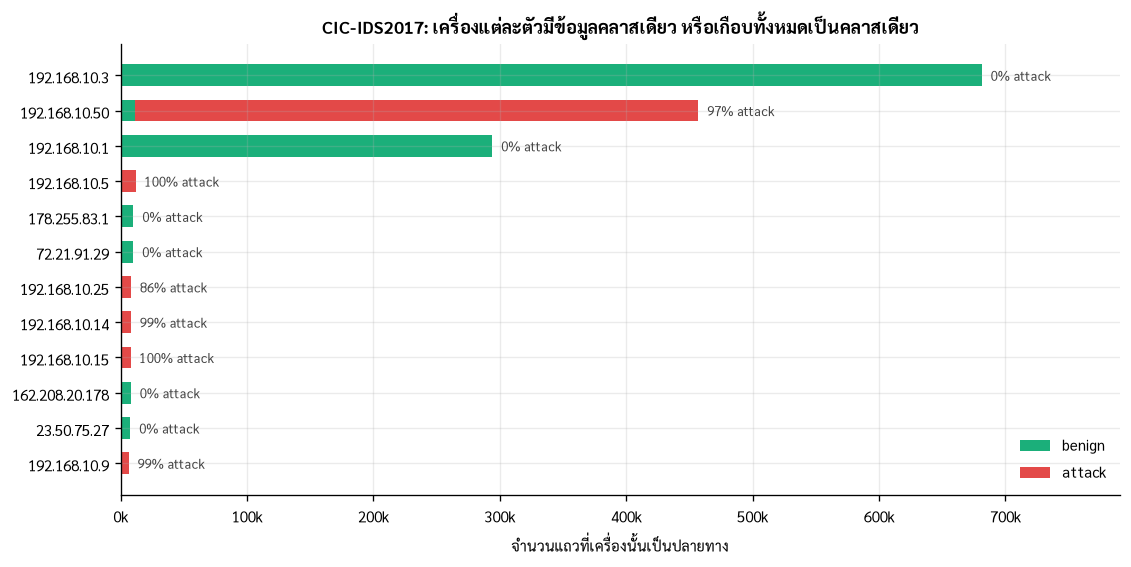

In [8]:
top = hosts.head(12).iloc[::-1]
fig, ax = plt.subplots(figsize=(9.5, 4.8))
ax.barh(top.index, top.rows * (1 - top.attack_rate), color=C["aqua"], label="benign", height=0.62)
ax.barh(top.index, top.rows * top.attack_rate, left=top.rows * (1 - top.attack_rate), color=C["red"],
        label="attack", height=0.62)
for i, (idx, r) in enumerate(top.iterrows()):
    ax.text(r.rows + top.rows.max() * 0.01, i, f"{r.attack_rate:.0%} attack", va="center", fontsize=8, color="#444")
ax.set_xlabel("จำนวนแถวที่เครื่องนั้นเป็นปลายทาง")
ax.set_title("CIC-IDS2017: เครื่องแต่ละตัวมีข้อมูลคลาสเดียว หรือเกือบทั้งหมดเป็นคลาสเดียว")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v/1000:,.0f}k"))
ax.legend(frameon=False)
ax.set_xlim(0, top.rows.max() * 1.16)
plt.tight_layout(); plt.show()

## 1.3 ข้ามวันได้ผลไหม (leave-one-day-out)

กันวันหนึ่งไว้ทดสอบ เทรนจากอีกสามวันที่เหลือ (จันทร์เป็น benign ล้วน ใช้เป็นข้อมูลเทรนได้แต่ทดสอบไม่ได้)
ใช้ฉบับ 79 คอลัมน์ ตัดคอลัมน์ `Destination Port` ทิ้งเพราะเป็นตัวชี้บริการที่ชี้ตรงไปยังชนิดการโจมตี ตัวปรับค่าว่างคำนวณจากฝั่งเทรนเท่านั้น

In [9]:
feat_cic = [c for c in S_orig.columns if c not in ("Label", "attack", "day", "Destination Port", "Fwd Header Length.1")]
S_orig[feat_cic] = S_orig[feat_cic].replace([np.inf, -np.inf], np.nan)

SEEDS = [0, 1, 2, 3, 4]          # RandomForest มีความสุ่ม จึงรันซ้ำ 5 seed แล้วรายงานค่าเฉลี่ยและ sd
lodo_rows = []
for held in ["tuesday", "wednesday", "thursday", "friday"]:
    tr, te = S_orig[S_orig.day != held], S_orig[S_orig.day == held]
    med = tr[feat_cic].median()
    Xtr, Xte = tr[feat_cic].fillna(med).to_numpy(np.float32), te[feat_cic].fillna(med).to_numpy(np.float32)
    aucs, recs, accs = [], [], []
    for seed in SEEDS:
        clf = RandomForestClassifier(n_estimators=100, max_depth=12, n_jobs=-1, random_state=seed).fit(Xtr, tr.attack)
        p = clf.predict_proba(Xte)[:, 1]; pred = (p > 0.5).astype(int)
        aucs.append(roc_auc_score(te.attack, p)); recs.append(recall_score(te.attack, pred))
        accs.append(accuracy_score(te.attack, pred))
    lodo_rows.append({"วันที่กันไว้": held, "แถวทดสอบ": len(te), "สัดส่วนโจมตี": round(te.attack.mean(), 3),
                      "AUC": round(np.mean(aucs), 3), "AUC sd": round(np.std(aucs), 3),
                      "recall": round(np.mean(recs), 3), "recall sd": round(np.std(recs), 3),
                      "accuracy": round(np.mean(accs), 3)})
lodo = pd.DataFrame(lodo_rows)
print(lodo.to_string(index=False))
print(f"\nเฉลี่ยข้ามวัน: AUC {lodo['AUC'].mean():.3f} (ต่ำสุด {lodo['AUC'].min():.2f} สูงสุด {lodo['AUC'].max():.2f}) · "
      f"attack recall {lodo['recall'].mean():.3f} (ต่ำสุด {lodo['recall'].min():.3f} สูงสุด {lodo['recall'].max():.3f})")
print("recall = สัดส่วนแถวโจมตีที่โมเดลจับได้ที่เกณฑ์ 0.5 · sd = ส่วนเบี่ยงเบนมาตรฐานข้าม 5 seed ของ RandomForest")

วันที่กันไว้  แถวทดสอบ  สัดส่วนโจมตี   AUC  AUC sd  recall  recall sd  accuracy
     tuesday     38835         0.356 0.792   0.024   0.000      0.000     0.642
   wednesday     50000         0.500 0.928   0.006   0.008      0.001     0.504
    thursday     52216         0.042 0.860   0.017   0.003      0.003     0.947
      friday    126966         0.409 0.695   0.015   0.262      0.052     0.697

เฉลี่ยข้ามวัน: AUC 0.819 (ต่ำสุด 0.69 สูงสุด 0.93) · attack recall 0.068 (ต่ำสุด 0.000 สูงสุด 0.262)
recall = สัดส่วนแถวโจมตีที่โมเดลจับได้ที่เกณฑ์ 0.5 · sd = ส่วนเบี่ยงเบนมาตรฐานข้าม 5 seed ของ RandomForest


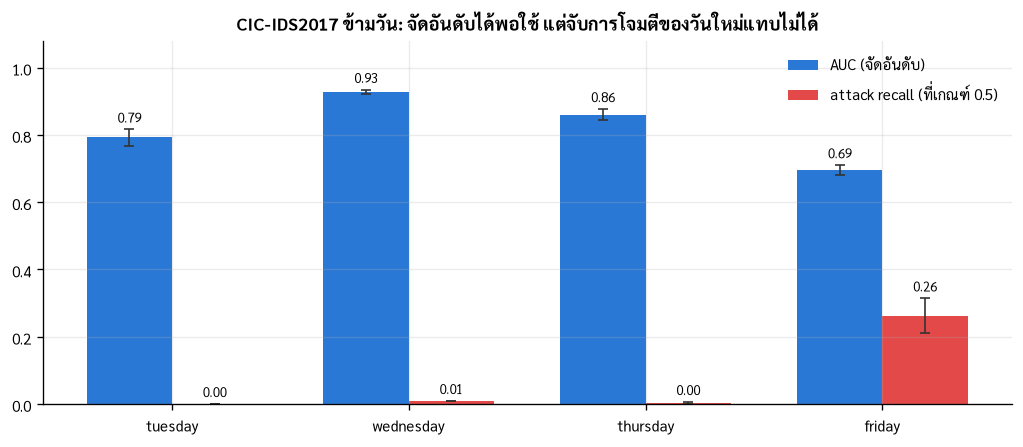

In [10]:
fig, ax = plt.subplots(figsize=(8.6, 3.8))
x = np.arange(len(lodo)); w = 0.36
ax.bar(x - w/2, lodo["AUC"], w, color=C["blue"], label="AUC (จัดอันดับ)")
ax.bar(x + w/2, lodo["recall"], w, color=C["red"], label="attack recall (ที่เกณฑ์ 0.5)")
ax.errorbar(x - w/2, lodo["AUC"], yerr=lodo["AUC sd"], fmt="none", ecolor="#333", capsize=3, linewidth=1)
ax.errorbar(x + w/2, lodo["recall"], yerr=lodo["recall sd"], fmt="none", ecolor="#333", capsize=3, linewidth=1)
for i, r in lodo.iterrows():
    ax.text(i - w/2, r["AUC"] + r["AUC sd"] + 0.02, f"{r['AUC']:.2f}", ha="center", fontsize=8)
    ax.text(i + w/2, r["recall"] + r["recall sd"] + 0.02, f"{r['recall']:.2f}", ha="center", fontsize=8)
ax.set_xticks(x, lodo["วันที่กันไว้"]); ax.set_ylim(0, 1.08)
ax.set_title("CIC-IDS2017 ข้ามวัน: จัดอันดับได้พอใช้ แต่จับการโจมตีของวันใหม่แทบไม่ได้")
ax.legend(frameon=False, loc="upper right")
plt.tight_layout(); plt.show()

### ผลนี้เสถียรแค่ไหน

RandomForest สุ่มได้ จึงรัน 5 seed และดู sd ข้างบนแล้ว (AUC ข้ามวันมี sd 0.006–0.024)
เซลล์ข้างล่างตรวจอีกข้อ: คอลัมน์ซ้ำ `Fwd Header Length.1` (ค่าเหมือน `Fwd Header Length` ทุกแถว) ทำให้ผลของวัน Friday เปลี่ยนไหม

In [11]:
tr_f, te_f = S_orig[S_orig.day != "friday"], S_orig[S_orig.day == "friday"]
feat_with_dup = feat_cic + ["Fwd Header Length.1"]
sens_rows = []
for name, cols in (("คงคอลัมน์ซ้ำไว้", feat_with_dup), ("ตัดคอลัมน์ซ้ำออก", feat_cic)):
    tmp = tr_f[cols].replace([np.inf, -np.inf], np.nan); med = tmp.median()
    Xtr, Xte = tmp.fillna(med).to_numpy(np.float32), te_f[cols].replace([np.inf, -np.inf], np.nan).fillna(med).to_numpy(np.float32)
    aucs = [roc_auc_score(te_f.attack, RandomForestClassifier(n_estimators=100, max_depth=12, n_jobs=-1, random_state=s)
                          .fit(Xtr, tr_f.attack).predict_proba(Xte)[:, 1]) for s in SEEDS]
    sens_rows.append({"ชุดฟีเจอร์": name, "AUC เฉลี่ย (Friday)": round(np.mean(aucs), 3), "sd": round(np.std(aucs), 3),
                      "ต่ำสุด": round(min(aucs), 3), "สูงสุด": round(max(aucs), 3)})
pd.DataFrame(sens_rows)

,ชุดฟีเจอร์,AUC เฉลี่ย (Friday),sd,ต่ำสุด,สูงสุด
0,คงคอลัมน์ซ้ำไว้,0.705,0.007,0.695,0.711
1,ตัดคอลัมน์ซ้ำออก,0.695,0.015,0.666,0.708


### อ่านผลหัวข้อ 1

- **S1** ฉบับต้นฉบับไม่มี IP แบ่งได้แค่ตามวัน ซึ่งเป็นแกน **เวลา** ไม่ใช่หน่วยงาน ฉบับที่มี IP แบ่งตามเครื่องได้ แต่เครื่องพวกนี้เป็นเครื่องในห้องทดลองเดียว ไม่ใช่องค์กรอิสระ
- **S2** แบ่งตามเครื่อง: จาก 15 เครื่องภายในที่มี ≥1,000 แถว มี **10 เครื่องเป็นคลาสเดียวเกือบทั้งหมด** — 4 เครื่องเป็น benign เกือบ 100%
  (รวมเครื่องที่ใหญ่ที่สุด 192.168.10.3 ที่ 681k แถว) และ 6 เครื่องเป็น attack ≥ 97% (เช่น 192.168.10.50 ที่ 457k แถว) อีก 5 เครื่องมีทั้งสองคลาส แต่ก็เป็น attack 86–91%
  แบ่งตามวัน: จันทร์เป็น benign ล้วน และการโจมตี 14 ชนิด **ไม่มีชนิดไหนปรากฏมากกว่าหนึ่งวัน**
- **S3** ฟีเจอร์เหมือนกันทุกวัน (78 ตัว หลังตัดคอลัมน์ซ้ำ)
- **S4** ข้ามวัน: AUC 0.69–0.93 (เฉลี่ย 0.82) แต่จับการโจมตีของวันที่ไม่เคยเห็นได้ **0–26% ที่เกณฑ์ปกติ (เฉลี่ย 7%)** หน่วยงานที่เจอการโจมตีตระกูลใหม่แทบไม่ได้ประโยชน์จากหน่วยงานอื่น
  ตารางความเสถียรข้างบนแสดงว่าคอลัมน์ซ้ำไม่ได้เปลี่ยนผลของ Friday อย่างมีนัย (0.705 เทียบ 0.695 ต่างกันเล็กน้อยใกล้เคียงความสุ่ม)
- **S5** แถวซ้ำ 9.1% · `inf` 4,376 เซลล์ · NaN 1,358 เซลล์ · `Flow Duration` ติดลบ 115 แถว · คอลัมน์ซ้ำ 1 คอลัมน์ · ป้ายต่างจากฉบับแก้แล้วหลายเท่า
  (DoS Hulk 231,073 เทียบ 158,468 · Web Attack Brute Force 1,507 เทียบ 73 ที่ยืนยัน + 1,292 "Attempted" · XSS 652 เทียบ 18 + 655)

---

# 2 · CICIoT2023

ทดสอบแบบสร้างการโจมตีจริงบนอุปกรณ์ IoT 105 ตัว เอกสารระบุ 33 การโจมตีใน 7 กลุ่ม (ไฟล์ที่ใช้มี 32 คลาสรวม benign) ไฟล์ CSV เป็นฟีเจอร์ระดับ flow
ใช้มิเรอร์ย่อ 1.34 ล้านแถว (ฉบับเต็มตามเปเปอร์มี ~46.7 ล้านแถว) เพราะเป้าหมายคือดู **โครงสร้าง** ไม่ใช่ทุกแถว

In [12]:
CI = DATA / "ciciot2023_raw" / "random"
ci = pd.concat([pd.read_parquet(CI / "train-00000-of-00001.parquet"),
                pd.read_parquet(CI / "test-00000-of-00001.parquet")], ignore_index=True)
label_cols = ["Label", "attack_class", "label"]
feat_ci = [c for c in ci.columns if c not in label_cols]
print(f"แถว {len(ci):,} · ฟีเจอร์ {len(feat_ci)} · คอลัมน์ป้าย {label_cols}")

id_like = [c for c in ci.columns if re.search(r"(^|[^a-z])(ip|mac|port|device|host|id)([^a-z]|$)", c.lower())
           and c not in ("IPv", "Protocol Type")]
print("คอลัมน์ที่บอกว่าแถวเป็นของอุปกรณ์/เครื่องไหน:", id_like or "ไม่มีเลย")
print("ฟีเจอร์ทั้งหมด:", feat_ci)

แถว 1,342,371 · ฟีเจอร์ 39 · คอลัมน์ป้าย ['Label', 'attack_class', 'label']
คอลัมน์ที่บอกว่าแถวเป็นของอุปกรณ์/เครื่องไหน: ไม่มีเลย
ฟีเจอร์ทั้งหมด: ['Header_Length', 'Protocol Type', 'Time_To_Live', 'Rate', 'fin_flag_number', 'syn_flag_number', 'rst_flag_number', 'psh_flag_number', 'ack_flag_number', 'ece_flag_number', 'cwr_flag_number', 'ack_count', 'syn_count', 'fin_count', 'rst_count', 'HTTP', 'HTTPS', 'DNS', 'Telnet', 'SMTP', 'SSH', 'IRC', 'TCP', 'UDP', 'DHCP', 'ARP', 'ICMP', 'IGMP', 'IPv', 'LLC', 'Tot sum', 'Min', 'Max', 'AVG', 'Std', 'Tot size', 'IAT', 'Number', 'Variance']


แถวซ้ำ 115,600 (8.6%) · NaN 100 เซลล์ · inf 57 เซลล์ · คอลัมน์ค่าคงที่ ไม่มี
จำนวนคลาสละเอียด: 32 | กลุ่มใหญ่: 8
benign ในมิเรอร์ย่อ: 14.9%   (README ของมิเรอร์ฉบับเต็ม 38.5 ล้านแถว ระบุ benign 2.9%)
คลาสที่มี 50,000 แถวพอดี: 21 จาก 32 คลาส · คลาสที่เล็กกว่า 50,000: 10 คลาส · benign 200,000 แถว
=> มิเรอร์นี้ตัดเพดานต่อคลาสไว้ที่ ~50,000 แถว สัดส่วนคลาสที่เห็นจึงไม่ใช่สัดส่วนจริงของข้อมูลต้นฉบับ


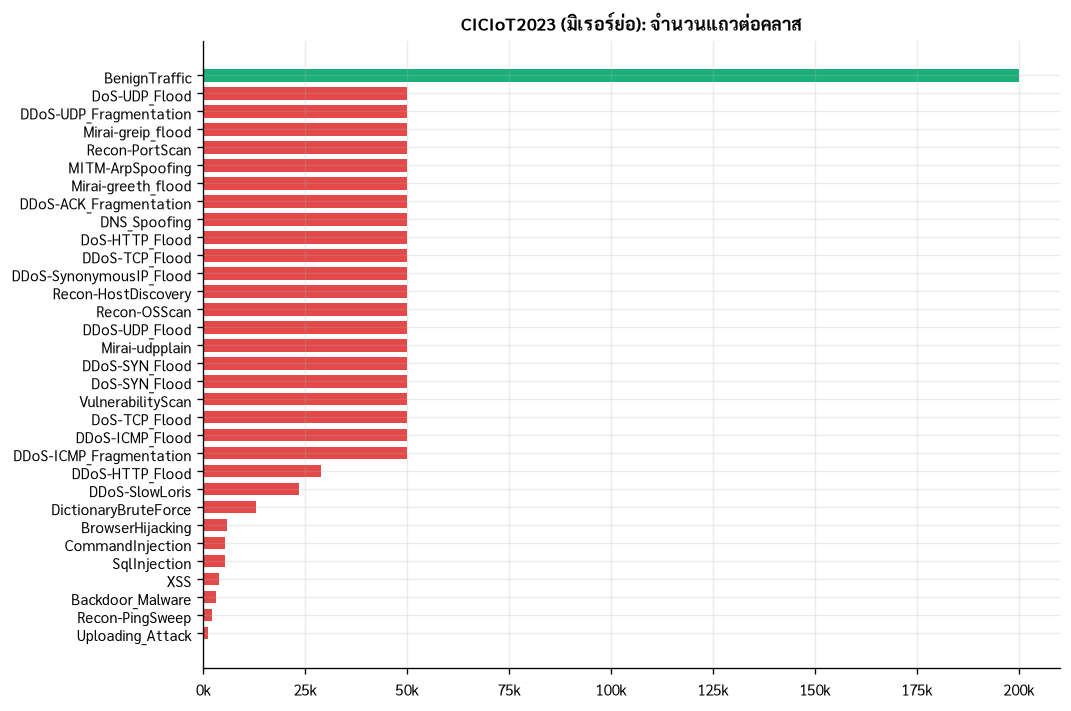

In [13]:
num = ci[feat_ci].select_dtypes("number")
ci_quality = {"dup_rate": ci.duplicated().mean(), "nan": int(num.isna().sum().sum()), "inf": int(np.isinf(num).sum().sum()),
              "const": [c for c in feat_ci if ci[c].nunique(dropna=True) <= 1]}
print(f"แถวซ้ำ {ci.duplicated().sum():,} ({ci_quality['dup_rate']:.1%}) · NaN {ci_quality['nan']} เซลล์ · inf {ci_quality['inf']} เซลล์ · คอลัมน์ค่าคงที่ {ci_quality['const'] or 'ไม่มี'}")
print("จำนวนคลาสละเอียด:", ci["Label"].nunique(), "| กลุ่มใหญ่:", ci["attack_class"].nunique() if "attack_class" in ci else "-")
print(f"benign ในมิเรอร์ย่อ: {(ci['label'] == 0).mean():.1%}   (README ของมิเรอร์ฉบับเต็ม 38.5 ล้านแถว ระบุ benign 2.9%)")

vc = ci["Label"].value_counts()
n_cap = int((vc == 50000).sum())
print(f"คลาสที่มี 50,000 แถวพอดี: {n_cap} จาก {len(vc)} คลาส · คลาสที่เล็กกว่า 50,000: {int((vc < 50000).sum())} คลาส · benign {vc.get('BenignTraffic', 0):,} แถว")
print("=> มิเรอร์นี้ตัดเพดานต่อคลาสไว้ที่ ~50,000 แถว สัดส่วนคลาสที่เห็นจึงไม่ใช่สัดส่วนจริงของข้อมูลต้นฉบับ")
fig, ax = plt.subplots(figsize=(9, 6))
colors = [C["aqua"] if k == "BenignTraffic" else C["red"] for k in vc.index[::-1]]
ax.barh(vc.index[::-1], vc.values[::-1], color=colors, height=0.7)
ax.set_title("CICIoT2023 (มิเรอร์ย่อ): จำนวนแถวต่อคลาส")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v/1000:,.0f}k"))
plt.tight_layout(); plt.show()

### อ่านผลหัวข้อ 2

- **S1 ไม่ผ่าน** ไม่มีคอลัมน์ IP, MAC, port หรือรหัสอุปกรณ์เลยในไฟล์นี้ วิธีแบ่ง "10 client ตามกลุ่มอุปกรณ์" ที่เปเปอร์
  Scientific Reports ใช้ **สร้างซ้ำจาก CSV ไม่ได้** ต้องย้อนไปใช้ pcap (มิเรอร์ HF ที่มี pcap ใหญ่ 605 GB)
- **S2/S4** วัดไม่ได้เพราะไม่มีหน่วยงานให้วัด
- **S5** แถวซ้ำ 8.6% มี NaN/inf เล็กน้อย 32 คลาสไม่สมดุลมาก ในฉบับเต็มบันทึกว่า benign เพียง 2.9%
- **ข้อควรระวังของมิเรอร์ย่อ:** 21 จาก 32 คลาสมี 50,000 แถวพอดี (คือถูกตัดเพดาน) อีก 10 คลาสเล็กกว่านั้น และ benign มี 200,000 แถว
  ดังนั้นสัดส่วน benign 14.9% ในมิเรอร์นี้ **ไม่ใช่** สัดส่วนจริง ตัวเลขนี้เทียบกับฉบับเต็มตรงๆ ไม่ได้
- **S6** ฉบับเต็มใหญ่ระดับ 46.7 ล้านแถว

---

# 3 · TON_IoT

ชุดนี้ต่างจากที่เหลือ เพราะแจกเป็นหลาย **แหล่งข้อมูลแยกกัน** ตั้งแต่ต้น: telemetry ของอุปกรณ์ IoT แต่ละประเภท ข้อมูลระบบปฏิบัติการ และ network
ดูเผินๆ เหมือนมีหน่วยงานให้แล้ว (S1 ผ่าน) ข้อนี้ตรวจว่าจริงไหม

## 3.1 IoT telemetry: 7 ประเภทอุปกรณ์

In [14]:
IOT = DATA / "toniot_iot"
iot, iot_schema = {}, {}
for f in sorted(IOT.glob("*.csv")):
    name = f.stem.replace("Train_Test_IoT_", "")
    d = pd.read_csv(f, encoding="utf-8-sig")
    iot[name] = d
    iot_schema[name] = [c for c in d.columns if c not in ("date", "time", "label", "type")]

iot_tbl = pd.DataFrame([{"อุปกรณ์": n, "แถว": len(d), "สัดส่วนโจมตี": round((d.label == 1).mean(), 3),
                         "ชนิดโจมตี": d.type.nunique() - 1, "ฟีเจอร์เซนเซอร์": ", ".join(iot_schema[n])}
                        for n, d in iot.items()])
print(iot_tbl.to_string(index=False))
feat_union = sorted(set().union(*map(set, iot_schema.values())))
shared_feat = sorted(set.intersection(*map(set, iot_schema.values())))
print(f"\nฟีเจอร์เซนเซอร์ที่ใช้ร่วมกันทั้ง 7 ประเภท: {shared_feat or 'ไม่มีเลย'}")
print(f"ฟีเจอร์เซนเซอร์ที่ไม่ซ้ำกันทั้งหมด: {len(feat_union)} ตัว")

     อุปกรณ์   แถว  สัดส่วนโจมตี  ชนิดโจมตี                                                                            ฟีเจอร์เซนเซอร์
      Fridge 39944         0.624          6                                                         fridge_temperature, temp_condition
 GPS_Tracker 38960         0.615          7                                                                        latitude, longitude
 Garage_Door 39587         0.621          7                                                                  door_state, sphone_signal
      Modbus 31106         0.518          5 FC1_Read_Input_Register, FC2_Read_Discrete_Value, FC3_Read_Holding_Register, FC4_Read_Coil
Motion_Light 39488         0.620          7                                                                motion_status, light_status
  Thermostat 32774         0.542          6                                                     current_temperature, thermostat_status
     Weather 39260         0.618          7            

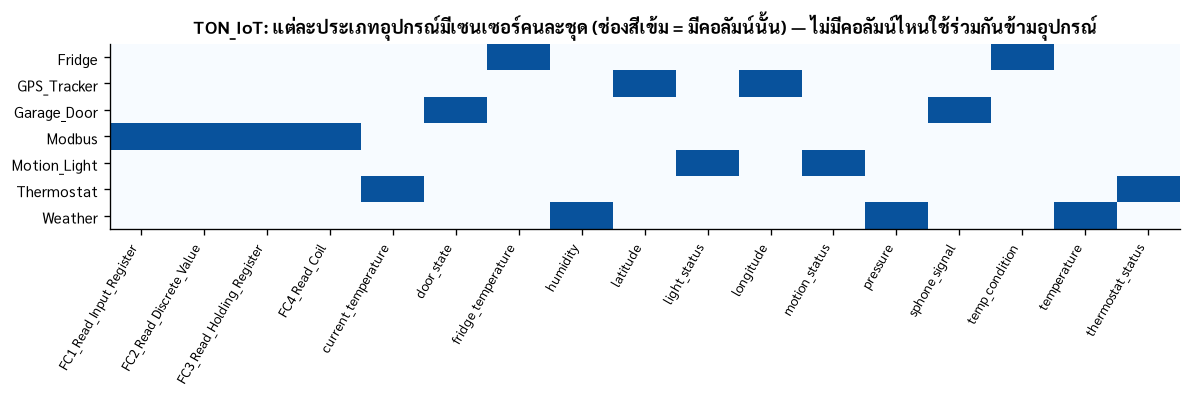

In [15]:
mat = pd.DataFrame({n: [int(f in iot_schema[n]) for f in feat_union] for n in iot_schema}, index=feat_union).T
fig, ax = plt.subplots(figsize=(10, 3.4))
ax.imshow(mat.values, cmap="Blues", aspect="auto", vmin=0, vmax=1.15)
ax.set_xticks(range(len(feat_union)), feat_union, rotation=60, ha="right", fontsize=8)
ax.set_yticks(range(len(mat)), mat.index)
ax.grid(False)
ax.set_title("TON_IoT: แต่ละประเภทอุปกรณ์มีเซนเซอร์คนละชุด (ช่องสีเข้ม = มีคอลัมน์นั้น) — ไม่มีคอลัมน์ไหนใช้ร่วมกันข้ามอุปกรณ์")
plt.tight_layout(); plt.show()

### timestamp บอกเฉลยได้ไหม

ทุกไฟล์มี `date` กับ `time` ตรวจว่าโมเดลที่ใช้ **แค่เวลา** (ไม่ดูค่าเซนเซอร์เลย) แยกโจมตี/ปกติได้แค่ไหน
เทียบกับโมเดลที่ใช้ค่าเซนเซอร์อย่างเดียว ถ้าเวลาอย่างเดียวได้ดีกว่า แปลว่าป้ายถูกกำหนดด้วยช่วงเวลาที่ทดลอง ไม่ใช่พฤติกรรมของอุปกรณ์

In [16]:
leak_rows = []
for name, d in iot.items():
    ts = pd.to_datetime(d["date"].str.strip() + " " + d["time"].str.strip(), format="%d-%b-%y %H:%M:%S", errors="coerce")
    ok = ts.notna().to_numpy()
    y = d["label"].to_numpy()[ok]
    tnum = (ts[ok].astype("int64").to_numpy() // 10**9).reshape(-1, 1)
    sens = pd.get_dummies(d.loc[ok, iot_schema[name]]).astype(float).to_numpy()
    def rf_auc(X, split):
        if split == "random":
            Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, stratify=y, random_state=0)
        else:
            order = np.argsort(tnum[:, 0]); cut = int(len(order) * 0.7)
            Xtr, Xte, ytr, yte = X[order[:cut]], X[order[cut:]], y[order[:cut]], y[order[cut:]]
        if len(set(yte)) < 2:
            return np.nan
        m = RandomForestClassifier(n_estimators=100, max_depth=12, n_jobs=-1, random_state=0).fit(Xtr, ytr)
        return roc_auc_score(yte, m.predict_proba(Xte)[:, 1])
    order = np.argsort(tnum[:, 0]); tail = y[order[int(len(order) * 0.7):]]
    leak_rows.append({"อุปกรณ์": name, "AUC ค่าเซนเซอร์อย่างเดียว": round(rf_auc(sens, "random"), 4),
                      "AUC เวลาอย่างเดียว": round(rf_auc(tnum, "random"), 4),
                      "ช่วงเวลา 30% หลังมีกี่คลาส": len(set(tail))})
leak = pd.DataFrame(leak_rows)
print(leak.to_string(index=False))

     อุปกรณ์  AUC ค่าเซนเซอร์อย่างเดียว  AUC เวลาอย่างเดียว  ช่วงเวลา 30% หลังมีกี่คลาส
      Fridge                     1.0000                 1.0                           1
 GPS_Tracker                     0.9639                 1.0                           1
 Garage_Door                     1.0000                 1.0                           1
      Modbus                     0.8676                 1.0                           1
Motion_Light                     0.5043                 1.0                           1
  Thermostat                     0.5106                 1.0                           1
     Weather                     0.9799                 1.0                           1


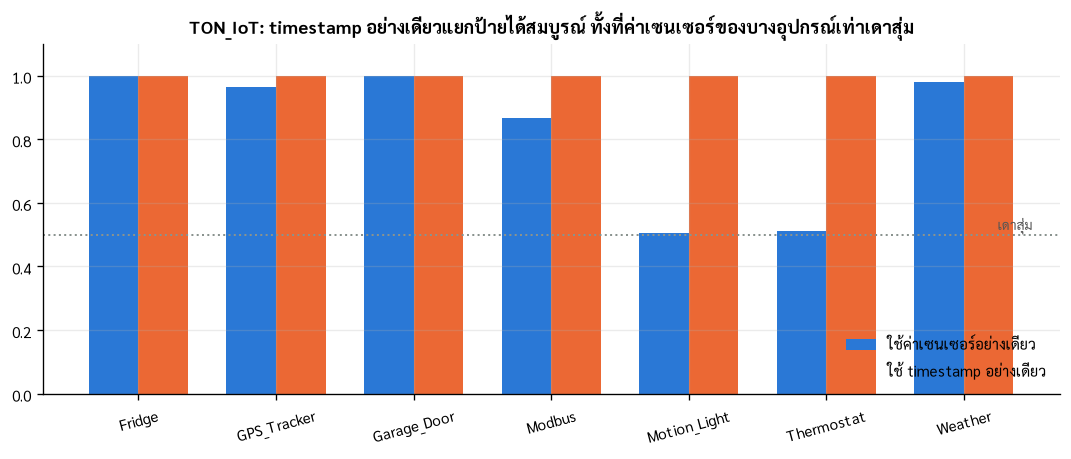

In [17]:
fig, ax = plt.subplots(figsize=(9, 3.9))
x = np.arange(len(leak)); w = 0.36
ax.bar(x - w/2, leak["AUC ค่าเซนเซอร์อย่างเดียว"], w, color=C["blue"], label="ใช้ค่าเซนเซอร์อย่างเดียว")
ax.bar(x + w/2, leak["AUC เวลาอย่างเดียว"], w, color=C["orange"], label="ใช้ timestamp อย่างเดียว")
ax.axhline(0.5, color=C["grey"], linestyle=":", linewidth=1.2)
ax.text(len(leak) - 0.5, 0.515, "เดาสุ่ม", ha="right", fontsize=8, color="#555")
ax.set_xticks(x, leak["อุปกรณ์"], rotation=15); ax.set_ylim(0, 1.1)
ax.set_title("TON_IoT: timestamp อย่างเดียวแยกป้ายได้สมบูรณ์ ทั้งที่ค่าเซนเซอร์ของบางอุปกรณ์เท่าเดาสุ่ม")
ax.legend(frameon=False, loc="lower right")
plt.tight_layout(); plt.show()

## 3.2 ข้อมูลระบบปฏิบัติการ (Windows / Linux)

In [18]:
OS = DATA / "toniot_os"
os_files, os_schema = [], {}
for f in sorted(OS.glob("*.csv")):
    name = f.stem.replace("Train_Test_", "").replace("Train_test_", "")
    if name.startswith("IoT_"):
        continue
    d = pd.read_csv(f, encoding="utf-8-sig", low_memory=False)
    os_schema[name] = set(d.columns)
    os_files.append({"ไฟล์": name, "แถว": len(d), "คอลัมน์": d.shape[1],
                     "สัดส่วนโจมตี": round((d["label"] == 1).mean(), 3) if "label" in d.columns else None})
print(pd.DataFrame(os_files).to_string(index=False))
names = list(os_schema)
jac = pd.DataFrame([[len(os_schema[a] & os_schema[b]) / len(os_schema[a] | os_schema[b]) for b in names] for a in names],
                   index=names, columns=names).round(2)
print("\nความเหมือนกันของชุดคอลัมน์ (Jaccard, 1.0 = เหมือนกันทุกคอลัมน์):")
jac

         ไฟล์   แถว  คอลัมน์  สัดส่วนโจมตี
Linux_process 90112       16         0.667
   Windows_10 21104      126         0.526
    Windows_7 15980      134         0.374
   linux_disk 90112        8           NaN
 linux_memory 70112       12         0.572

ความเหมือนกันของชุดคอลัมน์ (Jaccard, 1.0 = เหมือนกันทุกคอลัมน์):


,Linux_process,Windows_10,Windows_7,linux_disk,linux_memory
Linux_process,1.00,0.01,0.01,0.14,0.17
Windows_10,0.01,1.00,0.17,0.01,0.01
Windows_7,0.01,0.17,1.00,0.01,0.01
linux_disk,0.14,0.01,0.01,1.00,0.18
linux_memory,0.17,0.01,0.01,0.18,1.00


## 3.3 network: มี IP ให้แบ่งได้

In [19]:
net = pd.read_csv(DATA / "toniot_network" / "train_test_network.csv", encoding="utf-8-sig", low_memory=False)
print(f"แถว {len(net):,} · คอลัมน์ {net.shape[1]} · label 1 (โจมตี) {int((net.label == 1).sum()):,} · label 0 (ปกติ) {int((net.label == 0).sum()):,}")
print("ชนิด:", net["type"].value_counts().to_dict())
net_dup = int(net.duplicated().sum())
dash_cols = int(((net.astype(str) == "-").mean() > 0.9).sum())
print(f"แถวซ้ำ {net_dup:,} ({net_dup/len(net):.1%}) · คอลัมน์ที่ค่า '-' (ไม่มีข้อมูล) เกิน 90%: {dash_cols} จาก {net.shape[1]}")

src = silo_table(net, "src_ip", "label", min_rows=1000)
print("\nแบ่งตาม src_ip (≥1,000 แถว):", silo_summary(src))
src.round(3)

แถว 211,043 · คอลัมน์ 44 · label 1 (โจมตี) 161,043 · label 0 (ปกติ) 50,000
ชนิด: {'normal': 50000, 'backdoor': 20000, 'ddos': 20000, 'dos': 20000, 'injection': 20000, 'password': 20000, 'ransomware': 20000, 'scanning': 20000, 'xss': 20000, 'mitm': 1043}


แถวซ้ำ 20,569 (9.7%) · คอลัมน์ที่ค่า '-' (ไม่มีข้อมูล) เกิน 90%: 16 จาก 44

แบ่งตาม src_ip (≥1,000 แถว): {'หน่วยงาน': 16, 'มีทั้งสองคลาส': 1, 'คลาสเดียวหรือเกือบ': 15, 'ใหญ่/เล็ก': np.float64(48.9), 'gini': 0.606}


,rows,attack_rate,both_class
src_ip,,,
192.168.1.30,61633,0.999,False
192.168.1.31,30355,1.000,False
192.168.1.32,27227,1.000,False
192.168.1.193,25000,0.922,True
192.168.1.152,21893,0.000,False
192.168.1.33,9439,1.000,False
192.168.1.37,7500,1.000,False
192.168.1.195,4208,0.000,False
192.168.1.180,3708,0.000,False


### อ่านผลหัวข้อ 3

- **S1** ผ่านแบบมีเงื่อนไข: telemetry แยกตามประเภทอุปกรณ์ได้ 7 หน่วย network แยกตาม `src_ip` ได้
- **S2** telemetry มีทั้งสองคลาสทุกอุปกรณ์ (โจมตี 52–62%) แต่ network: จาก 16 IP ที่มี ≥1,000 แถว **15 IP เป็นคลาสเดียวเกือบทั้งหมด** (attack ≥ 99.9% หรือ ≈ 0%) มีแค่ 192.168.1.193 (attack 92%) ที่มีทั้งสองคลาส
- **S3 ไม่ผ่านอย่างแรง** telemetry ทั้ง 7 ประเภทไม่มีฟีเจอร์เซนเซอร์ร่วมกันเลย (รวม 17 ตัวไม่ซ้ำกัน) ไฟล์ OS ก็คนละชุดคอลัมน์ (Jaccard 0.01–0.18)
  โมเดลตัวเดียวใช้ร่วมกันข้ามหน่วยงานไม่ได้ นี่ไม่ใช่ horizontal swarm learning แบบที่ระบบนี้ทำ
- **S5** timestamp อย่างเดียวได้ AUC = 1.0 ทุกอุปกรณ์ ค่าเซนเซอร์ของ Motion_Light กับ Thermostat ได้ ~0.50 (เท่าเดาสุ่ม)
  แบ่งตามเวลาแล้วช่วงหลังมีคลาสเดียว · network มีแถวซ้ำ ~10%

---

# 4 · Edge-IIoTset

testbed IIoT ที่มีเซนเซอร์หลายชนิด (อุณหภูมิ, pH, ระดับน้ำ ฯลฯ) และโปรโตคอลอย่าง MQTT, Modbus
ฉบับที่ใช้คือ `ML-EdgeIIoT-dataset.csv` ที่คัดฟีเจอร์แล้ว ระดับ **packet** ไม่ใช่ flow

In [20]:
E = pd.read_csv(DATA / "edgeiiotset_ml" / "ML-EdgeIIoT-dataset.csv", low_memory=False)
print(f"แถว {len(E):,} · คอลัมน์ {E.shape[1]} · โจมตี {(E.Attack_label == 1).mean():.1%} · ชนิด {E.Attack_type.nunique()} (รวม Normal)")
num_e = E.select_dtypes("number")
zero_share = (num_e == 0).mean()
print(f"คอลัมน์ตัวเลข {num_e.shape[1]} · ที่เป็น 0 ตั้งแต่ 90% ขึ้นไป {int((zero_share >= 0.9).sum())} คอลัมน์ · ตั้งแต่ 99% ขึ้นไป {int((zero_share >= 0.99).sum())} คอลัมน์")
print(f"คอลัมน์ข้อความ {E.select_dtypes(exclude='number').shape[1]} · แถวซ้ำ {int(E.duplicated().sum()):,}")
ident_e = [c for c in E.columns if c in ("frame.time", "ip.src_host", "ip.dst_host", "tcp.srcport", "tcp.dstport", "tcp.seq", "tcp.ack_raw", "tcp.ack")]
print("คอลัมน์ที่เป็นตัวระบุ/ตัวนับเฉพาะแพ็กเก็ต (เสี่ยงรั่วเฉลย):", ident_e)

แถว 157,800 · คอลัมน์ 63 · โจมตี 84.6% · ชนิด 15 (รวม Normal)
คอลัมน์ตัวเลข 43 · ที่เป็น 0 ตั้งแต่ 90% ขึ้นไป 33 คอลัมน์ · ตั้งแต่ 99% ขึ้นไป 21 คอลัมน์
คอลัมน์ข้อความ 20 · แถวซ้ำ 814
คอลัมน์ที่เป็นตัวระบุ/ตัวนับเฉพาะแพ็กเก็ต (เสี่ยงรั่วเฉลย): ['frame.time', 'ip.src_host', 'ip.dst_host', 'tcp.ack', 'tcp.ack_raw', 'tcp.dstport', 'tcp.seq', 'tcp.srcport']


### คอลัมน์ `frame.time` มีค่าที่ไม่ใช่เวลา

พบว่าบางแถวคอลัมน์ `frame.time` เก็บค่าอย่าง `192.168.0.128`, `0.0`, `6.0` แทนที่จะเป็น timestamp วัดว่ากี่แถวและเกี่ยวกับป้ายไหม
ผมไม่ทราบว่าเกิดจากไฟล์ต้นฉบับหรือมิเรอร์ ควรเทียบกับไฟล์ต้นทางก่อนใช้

In [21]:
ft = E["frame.time"].astype(str)
is_ts = ft.str.contains(r"\d{1,2}:\d{2}:\d{2}", regex=True)
print(f"frame.time ที่ไม่ใช่เวลา: {int((~is_ts).sum()):,} แถว ({(~is_ts).mean():.1%})")
print("ค่าที่พบบ่อยในกลุ่มนี้:", ft[~is_ts].value_counts().head(3).to_dict())
bad_by_type = (E.assign(bad=~is_ts).groupby("Attack_type")
               .agg(แถว=("bad", "size"), สัดส่วนที่เสีย=("bad", "mean")).sort_values("สัดส่วนที่เสีย", ascending=False))
bad_by_type["สัดส่วนที่เสีย"] = bad_by_type["สัดส่วนที่เสีย"].round(3)
edge_bad_types = bad_by_type[bad_by_type["สัดส่วนที่เสีย"] > 0].index.tolist()
edge_bad_share = float((~is_ts).mean())
bad_by_type

frame.time ที่ไม่ใช่เวลา: 15,712 แถว (10.0%)
ค่าที่พบบ่อยในกลุ่มนี้: {'192.168.0.128': 1402, '0.0': 873, '6.0': 341}


,แถว,สัดส่วนที่เสีย
Attack_type,,
DDoS_UDP,14498,1.0
MITM,1214,1.0
Backdoor,10195,0.0
DDoS_HTTP,10561,0.0
DDoS_ICMP,14090,0.0
DDoS_TCP,10247,0.0
Fingerprinting,1001,0.0
Normal,24301,0.0
Password,9989,0.0


### แบ่งตามเครื่อง และตามโปรโตคอล

ผมแบ่งสองแบบ: (ก) ตาม `ip.src_host` ซึ่งเป็นสิ่งเดียวที่ชี้เครื่องได้ (ข) ตามโปรโตคอลที่ปรากฏในแพ็กเก็ต (MQTT, HTTP, ICMP ฯลฯ)
เป็นตัวแทน (proxy) ของ "แบ่งตามประเภทอุปกรณ์/แอปพลิเคชัน" ที่เปเปอร์อื่นใช้ **นี่คือวิธีของผมเอง ไม่ใช่วิธีของเปเปอร์นั้น**

In [22]:
edge_host = silo_table(E, "ip.src_host", "Attack_label", min_rows=500)
print("แบ่งตาม ip.src_host (≥500 แถว):", silo_summary(edge_host))
print(f"ip.src_host ที่ไม่ซ้ำ: {E['ip.src_host'].nunique():,} ค่า แต่ 3 เครื่องแรกมีแถวรวม "
      f"{edge_host.rows.iloc[:3].sum():,} จาก {len(E):,} ({edge_host.rows.iloc[:3].sum()/len(E):.0%})")
edge_host.round(3)

แบ่งตาม ip.src_host (≥500 แถว): {'หน่วยงาน': 4, 'มีทั้งสองคลาส': 2, 'คลาสเดียวหรือเกือบ': 2, 'ใหญ่/เล็ก': np.float64(9.1), 'gini': 0.418}
ip.src_host ที่ไม่ซ้ำ: 19,090 ค่า แต่ 3 เครื่องแรกมีแถวรวม 130,360 จาก 157,800 (83%)


,rows,attack_rate,both_class
ip.src_host,,,
192.168.0.128,72546,0.860,True
192.168.0.170,47688,1.000,False
192.168.0.101,10126,0.015,False
0,7991,0.476,True


In [23]:
def present(col):
    return ~E[col].astype(str).isin(["0", "0.0", "0.0.0.0", "nan", ""])
proto = pd.Series("other", index=E.index)
for name, cond in [("mqtt", present("mqtt.msgtype")), ("modbus", present("mbtcp.len")), ("dns", present("dns.qry.name")),
                   ("http", present("http.request.method") | present("http.response")), ("icmp", present("icmp.checksum")),
                   ("arp", present("arp.opcode")), ("udp", present("udp.port"))]:
    proto[cond & (proto == "other")] = name
proto[(proto == "other") & present("tcp.srcport")] = "tcp"
E["proto"] = proto

proto_tbl = silo_table(E, "proto", "Attack_label", min_rows=100)
proto_tbl["ชนิดโจมตี"] = E.groupby("proto").Attack_type.apply(lambda s: s[s != "Normal"].nunique())
print("แบ่งตามโปรโตคอล (proxy):", silo_summary(proto_tbl))
proto_tbl.round(3)

แบ่งตามโปรโตคอล (proxy): {'หน่วยงาน': 8, 'มีทั้งสองคลาส': 2, 'คลาสเดียวหรือเกือบ': 6, 'ใหญ่/เล็ก': np.float64(778.1), 'gini': 0.735}


,rows,attack_rate,both_class,ชนิดโจมตี
proto,,,,
tcp,117498,0.838,True,12
icmp,14670,1.000,False,2
http,14415,1.000,False,6
mqtt,5063,0.000,False,0
other,2773,0.975,False,12
dns,1656,0.984,False,2
arp,1574,0.973,False,9
udp,151,0.927,True,1


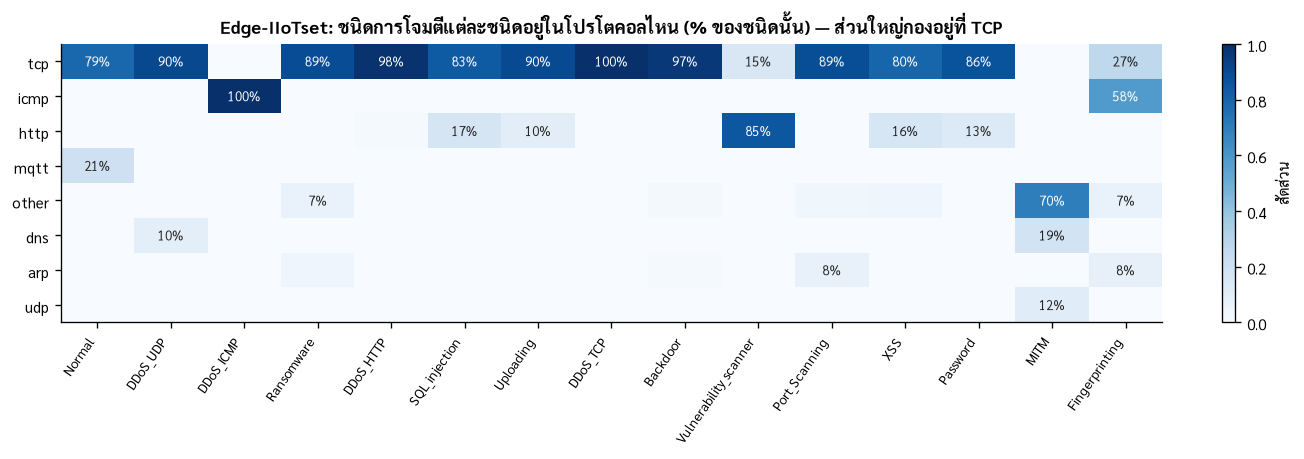

In [24]:
ct = pd.crosstab(E["proto"], E["Attack_type"])
ct = ct.loc[proto_tbl.index, ct.sum().sort_values(ascending=False).index]
share = ct.div(ct.sum(axis=0), axis=1)          # ชนิดโจมตีนี้ อยู่ในโปรโตคอลไหนกี่ %
fig, ax = plt.subplots(figsize=(11, 3.9))
im = ax.imshow(share.values, cmap="Blues", aspect="auto", vmin=0, vmax=1)
ax.set_xticks(range(share.shape[1]), share.columns, rotation=55, ha="right", fontsize=8)
ax.set_yticks(range(share.shape[0]), share.index); ax.grid(False)
for i in range(share.shape[0]):
    for j in range(share.shape[1]):
        v = share.iat[i, j]
        if v >= 0.05:
            ax.text(j, i, f"{v:.0%}", ha="center", va="center", fontsize=7.5, color="white" if v > 0.5 else "#222")
ax.set_title("Edge-IIoTset: ชนิดการโจมตีแต่ละชนิดอยู่ในโปรโตคอลไหน (% ของชนิดนั้น) — ส่วนใหญ่กองอยู่ที่ TCP")
plt.colorbar(im, ax=ax, fraction=0.02, label="สัดส่วน")
plt.tight_layout(); plt.show()

### อ่านผลหัวข้อ 4

- **S1** ตัวระบุเครื่องมีแค่ IP และ **มีเครื่องจริงที่มีข้อมูลเยอะแค่ 3 เครื่อง** จาก 19,090 ค่า `ip.src_host` (ที่เหลือ 19,086 ค่าส่วนใหญ่ปรากฏแถวเดียว รวม 19,449 แถว เป็น attack 99.9% ส่วนใหญ่ DDoS พร้อมค่าแทน `0` อีก 7,991 แถว)
  ไม่ใช่อุปกรณ์ IoT หลายสิบตัว การแบ่ง "6 client ตามประเภทอุปกรณ์" ที่เปเปอร์อื่นใช้ **สร้างซ้ำจาก CSV นี้ไม่ได้**
- **S2** แบ่งตามโปรโตคอลได้ 8 กลุ่ม แต่ **TCP กลุ่มเดียวมี 74% ของแถวและมีการโจมตี 12 ชนิด** ที่เหลือเกือบทั้งหมดเป็นคลาสเดียว
  (ICMP กับ HTTP เป็น attack 100% · MQTT เป็น benign 100%) มีแค่ 2 จาก 8 กลุ่มที่มีทั้งสองคลาส และมีเพียง 5 จาก 15 คลาส (รวม Normal) ที่ ≥90% ของแถวอยู่ในโปรโตคอลเดียว
  (ดู heatmap: DDoS_ICMP และ DDoS_TCP อยู่ในกลุ่มเดียว 100% แต่ XSS, SQL injection, DDoS_HTTP ส่วนใหญ่ถูกจัดเป็น TCP เพราะไม่พบฟิลด์ HTTP ในแถวนั้น)
  สรุป: **proxy นี้ไม่ได้ให้หน่วยงานที่สมดุล** ได้กลุ่มยักษ์หนึ่งกลุ่มกับกลุ่มเล็กที่เป็นคลาสเดียว และเป็นวิธีที่ผมเลือกเอง ไม่ใช่การแบ่งตามอุปกรณ์จริง
- **S5** 10% ของแถวมี `frame.time` ไม่ใช่เวลา และเกิดใน **DDoS_UDP 100% กับ MITM 100% เท่านั้น** (คลาสอื่น 0%) เป็นสิ่งแปลกปลอมที่ชี้ป้ายได้ตรงๆ ·
  คอลัมน์ 0 เกือบทั้งคอลัมน์ 33 จาก 43 · มีคอลัมน์ตัวระบุ (IP, port, sequence number) ที่เสี่ยงรั่วเฉลย · ฉบับ ML นี้เป็นระดับ packet ต่างจากฉบับ DNN ที่ใหญ่กว่ามาก

---

# 5 · TII-SSRC-23 (ไม่ได้วัด)

**โหลดไม่ได้ในเครื่องนี้**: ที่เดียวที่แจกคือ Kaggle ซึ่งต้องล็อกอิน (ลองเรียก API แบบไม่ล็อกอินได้ 404) และไม่พบมิเรอร์บน HuggingFace
จึง **ไม่มีตัวเลขที่วัดเองในหัวข้อนี้** ข้อมูลข้างล่างมาจากเอกสารอย่างเดียว

| รายการ | ค่าที่เอกสารระบุ | ที่มา |
|---|---|---|
| ขนาด pcap | 27.5 GB | เปเปอร์ IEEE Access 2023 (ผ่านผลค้นหา) |
| จำนวนประเภททราฟฟิก | 32 ประเภทย่อย · การโจมตี 26 ชนิด | เช่นเดียวกัน |
| ฟีเจอร์ / จำนวนแถวที่ใช้ในเปเปอร์เทียบ | 79 ฟีเจอร์ · ~8.7 ล้าน flow | Scientific Reports (สรุปผ่านเครื่องมืออ่านหน้าเว็บ ยังไม่ได้อ่านตัวเปเปอร์เต็ม) |
| วิธีแบ่ง client ในเปเปอร์นั้น | **5 client แบบสุ่ม flow (stratified)** ทุก client ได้ทุกชนิดทราฟฟิก "เกือบ i.i.d." | เช่นเดียวกัน |
| ผลที่เปเปอร์นั้นรายงาน | accuracy ≈ 95% ต่ำกว่าอีกสองชุดเล็กน้อย เพราะป้ายละเอียดกว่า | เช่นเดียวกัน |

### สิ่งที่พอสรุปได้จากเอกสาร (ไม่ใช่จากข้อมูล)

- ไม่มีวิธีแบ่งตามหน่วยงานตามธรรมชาติที่เผยแพร่ วิธีเดียวที่รู้คือสุ่ม ซึ่ง **เกือบ i.i.d. ตามที่เปเปอร์บันทึกเอง**
  จึงเป็นสถานการณ์ที่ง่ายที่สุดสำหรับ federated learning และไม่ได้ทดสอบสิ่งที่ swarm learning มีไว้แก้ (ข้อมูลไม่เท่ากันข้ามหน่วยงาน)
- ถ้าจะประเมินจริงต้องมีบัญชี Kaggle แล้วดาวน์โหลดเอง (CSV ฟีเจอร์ขนาดเล็กกว่า pcap มาก) ผมไม่ได้ตรวจขนาดของ CSV

---

# 6 · สรุปเทียบทั้งห้าชุด

ตัวเลขในตารางดึงจากตัวแปรที่คำนวณข้างบน (ยกเว้นแถว N-BaIoT ที่เป็นค่าอ้างอิงจากโน้ตบุ๊กก่อนหน้า `N-BaIoT_Kitsune.ipynb`)

In [25]:
n_iot_both = int(((iot_tbl["สัดส่วนโจมตี"] >= 0.05) & (iot_tbl["สัดส่วนโจมตี"] <= 0.95)).sum())
sens_low = leak[leak["AUC ค่าเซนเซอร์อย่างเดียว"] < 0.6]["อุปกรณ์"].tolist()
edge_single = int((~proto_tbl.both_class).sum())
summary = pd.DataFrame([
    {"ชุดข้อมูล": "N-BaIoT (อ้างอิง)", "S1 ตัวระบุหน่วยงาน": "มี · 9 อุปกรณ์",
     "S2 มีทั้งสองคลาส": "9 จาก 9", "S3 ฟีเจอร์ตรงกัน": "ตรงทุกหน่วยงาน (115)",
     "S4 ข้ามหน่วยงาน": "ได้ผล · accuracy 98.3%", "S5 คุณภาพ": "pcc หลุดช่วง 2.6%", "S6 ขนาดที่โหลด": "1.7 GB"},
    {"ชุดข้อมูล": "CIC-IDS2017", "S1 ตัวระบุหน่วยงาน": "ต้นฉบับ: ไม่มี (มีแค่วัน) · ฉบับแก้: มี IP ",
     "S2 มีทั้งสองคลาส": f"เครื่อง: {silo_summary(internal)['มีทั้งสองคลาส']} จาก {len(internal)} · วัน: {day_5pct} จาก 5 (มีทั้งสองคลาสแต่ attack น้อยมากอีก {day_any_both - day_5pct})",
     "S3 ฟีเจอร์ตรงกัน": "ตรงทุกวัน (78)", "S4 ข้ามหน่วยงาน": f"AUC {lodo['AUC'].mean():.2f} แต่ recall {lodo['recall'].mean():.2f}",
     "S5 คุณภาพ": f"ซ้ำ {quality['dup']/quality['rows']:.0%} · ป้ายต่างจากฉบับแก้หลายเท่า", "S6 ขนาดที่โหลด": "0.9 GB (2 ฉบับรวม 1.7 GB)"},
    {"ชุดข้อมูล": "CICIoT2023", "S1 ตัวระบุหน่วยงาน": "ไม่มีเลย", "S2 มีทั้งสองคลาส": "วัดไม่ได้",
     "S3 ฟีเจอร์ตรงกัน": "ตรง (39) แต่ไม่มีหน่วยงาน", "S4 ข้ามหน่วยงาน": "วัดไม่ได้",
     "S5 คุณภาพ": f"ซ้ำ {ci_quality['dup_rate']:.0%} · 32 คลาสเอียง", "S6 ขนาดที่โหลด": "มิเรอร์ย่อ 0.07 GB · ฉบับเต็ม ~46.7M แถว"},
    {"ชุดข้อมูล": "TON_IoT", "S1 ตัวระบุหน่วยงาน": "มี · 7 ประเภทอุปกรณ์ (telemetry)",
     "S2 มีทั้งสองคลาส": f"telemetry {n_iot_both} จาก 7 · network {silo_summary(src)['มีทั้งสองคลาส']} จาก {len(src)} IP",
     "S3 ฟีเจอร์ตรงกัน": f"ไม่ตรงเลย (เซนเซอร์ร่วม {len(shared_feat)} จาก {len(feat_union)})", "S4 ข้ามหน่วยงาน": "ทำไม่ได้ (ฟีเจอร์ต่าง)",
     "S5 คุณภาพ": f"timestamp อย่างเดียว AUC {leak['AUC เวลาอย่างเดียว'].min():.1f} · เซนเซอร์เท่าเดาสุ่ม {len(sens_low)} จาก 7", "S6 ขนาดที่โหลด": "0.09 GB"},
    {"ชุดข้อมูล": "Edge-IIoTset", "S1 ตัวระบุหน่วยงาน": "IP แต่มีเครื่องจริง 3 เครื่อง",
     "S2 มีทั้งสองคลาส": f"โปรโตคอล (proxy): {silo_summary(proto_tbl)['มีทั้งสองคลาส']} จาก {len(proto_tbl)}",
     "S3 ฟีเจอร์ตรงกัน": "ตรง (61)", "S4 ข้ามหน่วยงาน": "ไม่ได้วัด (proxy ไม่สมดุล: TCP 74% ที่เหลือคลาสเดียว)",
     "S5 คุณภาพ": f"frame.time เสีย {edge_bad_share:.0%} เฉพาะ {len(edge_bad_types)} คลาส", "S6 ขนาดที่โหลด": "0.08 GB (ฉบับ ML)"},
    {"ชุดข้อมูล": "TII-SSRC-23", "S1 ตัวระบุหน่วยงาน": "ไม่ได้วัด (เอกสาร: สุ่ม 5 client)", "S2 มีทั้งสองคลาส": "ไม่ได้วัด",
     "S3 ฟีเจอร์ตรงกัน": "ไม่ได้วัด", "S4 ข้ามหน่วยงาน": "ไม่ได้วัด", "S5 คุณภาพ": "ไม่ได้วัด",
     "S6 ขนาดที่โหลด": "27.5 GB (pcap) · ต้อง Kaggle login"},
]).set_index("ชุดข้อมูล")
summary

,S1 ตัวระบุหน่วยงาน,S2 มีทั้งสองคลาส,S3 ฟีเจอร์ตรงกัน,S4 ข้ามหน่วยงาน,S5 คุณภาพ,S6 ขนาดที่โหลด
ชุดข้อมูล,,,,,,
N-BaIoT (อ้างอิง),มี · 9 อุปกรณ์,9 จาก 9,ตรงทุกหน่วยงาน (115),ได้ผล · accuracy 98.3%,pcc หลุดช่วง 2.6%,1.7 GB
CIC-IDS2017,ต้นฉบับ: ไม่มี (มีแค่วัน) · ฉบับแก้: มี IP,เครื่อง: 5 จาก 15 · วัน: 2 จาก 5 (มีทั้งสองคลา...,ตรงทุกวัน (78),AUC 0.82 แต่ recall 0.07,ซ้ำ 9% · ป้ายต่างจากฉบับแก้หลายเท่า,0.9 GB (2 ฉบับรวม 1.7 GB)
CICIoT2023,ไม่มีเลย,วัดไม่ได้,ตรง (39) แต่ไม่มีหน่วยงาน,วัดไม่ได้,ซ้ำ 9% · 32 คลาสเอียง,มิเรอร์ย่อ 0.07 GB · ฉบับเต็ม ~46.7M แถว
TON_IoT,มี · 7 ประเภทอุปกรณ์ (telemetry),telemetry 7 จาก 7 · network 1 จาก 16 IP,ไม่ตรงเลย (เซนเซอร์ร่วม 0 จาก 17),ทำไม่ได้ (ฟีเจอร์ต่าง),timestamp อย่างเดียว AUC 1.0 · เซนเซอร์เท่าเดา...,0.09 GB
Edge-IIoTset,IP แต่มีเครื่องจริง 3 เครื่อง,โปรโตคอล (proxy): 2 จาก 8,ตรง (61),ไม่ได้วัด (proxy ไม่สมดุล: TCP 74% ที่เหลือคลา...,frame.time เสีย 10% เฉพาะ 2 คลาส,0.08 GB (ฉบับ ML)
TII-SSRC-23,ไม่ได้วัด (เอกสาร: สุ่ม 5 client),ไม่ได้วัด,ไม่ได้วัด,ไม่ได้วัด,ไม่ได้วัด,27.5 GB (pcap) · ต้อง Kaggle login


## ทำไมควร / ไม่ควรใช้กับ swarm learning

**ข้อสรุปรวม:** ในสี่ชุดที่วัดจากข้อมูลจริง ไม่มีชุดไหนมีครบทั้งสามอย่างพร้อมกัน (TII-SSRC-23 ไม่ได้วัด) — (1) ตัวระบุหน่วยงานที่อยู่ในข้อมูลเอง (2) ฟีเจอร์ชุดเดียวกันข้ามหน่วยงาน (3) ข้อมูลปกติและโจมตีอยู่ในทุกหน่วยงาน
ซึ่ง N-BaIoT มีครบ นี่คือเหตุผลที่ตัดสินใจถูกต้องแล้วในรอบแรก และตอนนี้มีตัวเลขรองรับ

| ชุด | ทำไมอาจอยากใช้ | ทำไมไม่ควรใช้เป็นแกนหลัก |
|---|---|---|
| **CIC-IDS2017** | ใช้แพร่หลาย เทียบผลกับงานอื่นได้ มีฉบับแก้ป้าย ฟีเจอร์ครบ | ไม่มีหน่วยงานตามธรรมชาติ (แบ่งตามวัน = แกนเวลา / ตามเครื่อง = เอียงสุดขั้ว) แต่ละวันโจมตีคนละตระกูล ข้ามวันจับการโจมตีใหม่ไม่ได้ · แถวซ้ำ 9% · ป้ายต้นฉบับต่างจากฉบับแก้หลายเท่า |
| **CICIoT2023** | ใหญ่ที่สุด อุปกรณ์เยอะ การโจมตีหลากหลาย เหมาะเป็น benchmark รวมศูนย์ | CSV ไม่มีตัวระบุอุปกรณ์เลย จะแบ่งต้องสังเคราะห์ ซึ่งคือปัญหาเดิมที่พยายามหนี · ฉบับเต็มใหญ่มาก |
| **TON_IoT** | มีหน่วยงานตามธรรมชาติตั้งแต่แรก (ประเภทอุปกรณ์) หลายรูปแบบข้อมูล | ฟีเจอร์คนละชุดกันหมด โมเดลเดียวใช้ร่วมไม่ได้ · timestamp บอกเฉลยได้ · เหมาะกับงานวิจัย federated แบบฟีเจอร์ต่างกัน (heterogeneous) มากกว่า swarm แบบเดิม |
| **Edge-IIoTset** | testbed IIoT จริงจัง มีโปรโตคอลอุตสาหกรรม (MQTT/Modbus) | มีเครื่องจริงแค่ 3 เครื่อง แบ่งตามประเภทอุปกรณ์จาก CSV ไม่ได้ · แบ่งตามโปรโตคอลได้กลุ่ม TCP ยักษ์ 74% กับกลุ่มเล็กคลาสเดียว · `frame.time` เสียเฉพาะสองคลาส · ระดับ packet คอลัมน์ 0 เกือบหมด |
| **TII-SSRC-23** | ทราฟฟิกหลากหลายทันสมัย (วิดีโอ เสียง IoT) การโจมตี 26 ชนิด | (จากเอกสารเท่านั้น) วิธีแบ่งที่รู้คือสุ่ม = เกือบ i.i.d. ไม่ทดสอบจุดแข็งของ swarm · ต้อง Kaggle login · ไม่ได้วัดเอง |

## เงื่อนไขที่ยังพอใช้ได้ (ไม่ใช่แกนหลัก)

- **CIC-IDS2017 ฉบับแก้ป้าย** ใช้เป็นชุดทดสอบ "ตระกูลการโจมตีใหม่" ได้ ถ้าต้องการวัดว่า swarm รับมือการโจมตีที่โหนดหนึ่งเจอแต่โหนดอื่นไม่เคยเจอได้ไหม
  (แต่ต้องยอมรับว่า partition เป็นของที่เราสร้างเอง)
- **TON_IoT telemetry** ใช้ได้ถ้าเปลี่ยนโจทย์เป็น federated learning ที่ฟีเจอร์ต่างกันต่อหน่วยงาน และตัด `date`/`time` ออกก่อนเทรน
- **CICIoT2023** ใช้เป็นชุดเทรนรวมศูนย์ขนาดใหญ่เพื่อเทียบว่า swarm ทำได้ใกล้เคียงโมเดลรวมศูนย์แค่ไหน

## ข้อจำกัดของโน้ตบุ๊กนี้

- ทุกตัวเลขมาจาก **มิเรอร์บุคคลที่สาม** ยกเว้น TII-SSRC-23 ที่ไม่ได้วัด ควรเทียบกับไฟล์ต้นทางก่อนอ้างในรายงาน (โดยเฉพาะปัญหา `frame.time` ของ Edge-IIoTset และแถวซ้ำ)
- โมเดลทดสอบเป็น RandomForest ไม่จูน ตัวอย่างต่อวันจำกัดที่ 25,000 แถวต่อคลาส (สุ่มครั้งเดียว) ส่วนเบี่ยงเบนที่รายงานคือข้าม seed ของ RandomForest เท่านั้น ไม่รวมความแปรผันจากการสุ่มตัวอย่าง
- การแบ่ง "ตามโปรโตคอล" ของ Edge-IIoTset เป็นวิธีของผมเอง ไม่ใช่วิธีที่เปเปอร์อื่นใช้
- CICIoT2023 วัดบนมิเรอร์ย่อ 1.34 ล้านแถว ไม่ใช่ฉบับเต็ม